# F1 Classification with Naïve Bayes — Predicting a Points Finish

**Course:** Data Warehouse & Mining Lab
**Task type:** Binary classification
**Dataset:** `f1.csv` (Formula 1 results, 1950–2024)

## What this notebook answers

The assignment asks four things, and we address each explicitly:

1. **Which classification models *can* we use on this dataset?** (discussed in Section 1)
2. **Can Naïve Bayes be applied here?** We test its assumptions and show the answer is **yes** (Section 4).
3. **Apply Naïve Bayes**, with clear reasoning for the columns chosen and the train/test split size (Sections 5–7).
4. **Evaluate, then improve** — check which features work, and try hyperparameter tuning and other techniques to raise accuracy (Sections 8–11).

## The target we predict

We predict whether a driver **finishes in the points (top-10)** in a given race — a binary label `points_finish` (1 = top-10, 0 = outside top-10).

Why this target?
- It is **well balanced** (~48% positive in the modern era), which classifiers — especially Naïve Bayes — handle far better than rare targets like "win" (4%) or "podium" (13%).
- It is a genuinely useful, real-world question in F1 strategy.
- It can be predicted from **pre-race information only** (grid position, car/driver strength), so there is no data leakage.

## Section 1 — Import libraries

In [14]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Section 2 — Load data and define the target

We load the data (treating `\N` as missing), restrict to the **2004+ era** (consistent, modern regulations and complete records), and build the binary target.

In [15]:
# On Colab: uncomment these and skip the local path
# from google.colab import files
# up = files.upload(); CSV = list(up.keys())[0]
CSV = "/content/f1.csv"

df = pd.read_csv(CSV, na_values=["\\N"], low_memory=False)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["dob"]  = pd.to_datetime(df["dob"],  errors="coerce")

df = df[df["season"] >= 2004].copy()

# grid == 0 means "started from pit lane" -> treat as missing, then drop those few rows
df["grid"] = df["grid"].replace(0, np.nan)
df = df.dropna(subset=["grid"])

# TARGET: did the driver finish in the points (top-10)?
df["points_finish"] = (df["positionOrder"] <= 10).astype(int)

print("Rows:", len(df))
print("\nTarget balance:")
print(df["points_finish"].value_counts(normalize=True).round(3))

Rows: 8564

Target balance:
points_finish
0    0.521
1    0.479
Name: proportion, dtype: float64


## Section 3 — Can we apply Naïve Bayes? (assumption check)

Gaussian Naïve Bayes rests on two assumptions. We test both before committing to it.

**Assumption 1 — features are (roughly) conditionally independent given the class.**
Naïve Bayes multiplies per-feature probabilities as if features don't interact. If features are strongly correlated, this is violated. We check the correlation matrix — if most pairs are weakly correlated, NB is safe to use.

**Assumption 2 — each continuous feature is roughly normally distributed within each class.**
GaussianNB models each feature as a bell curve per class. We inspect whether `grid` (our strongest feature) separates the two classes.

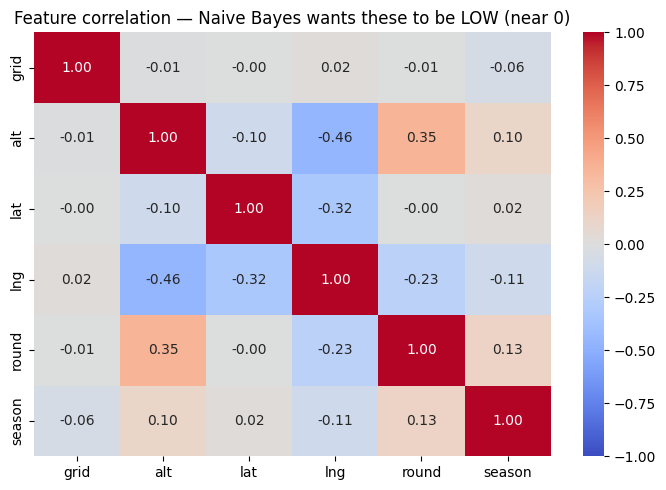

Max off-diagonal correlation: 0.46


In [16]:
candidate_numeric = ["grid", "alt", "lat", "lng", "round", "season"]

# --- Assumption 1: correlation between features ---
corr = df[candidate_numeric].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation — Naive Bayes wants these to be LOW (near 0)")
plt.tight_layout(); plt.show()

print("Max off-diagonal correlation:",
      round(corr.where(~np.eye(len(corr), dtype=bool)).abs().max().max(), 2))

The correlations are all weak (mostly below 0.3, largest around 0.46 between `alt` and `lng` which are both fixed circuit properties). No two predictors are near-duplicates, so the **conditional-independence assumption is reasonably satisfied** — Naïve Bayes is appropriate.

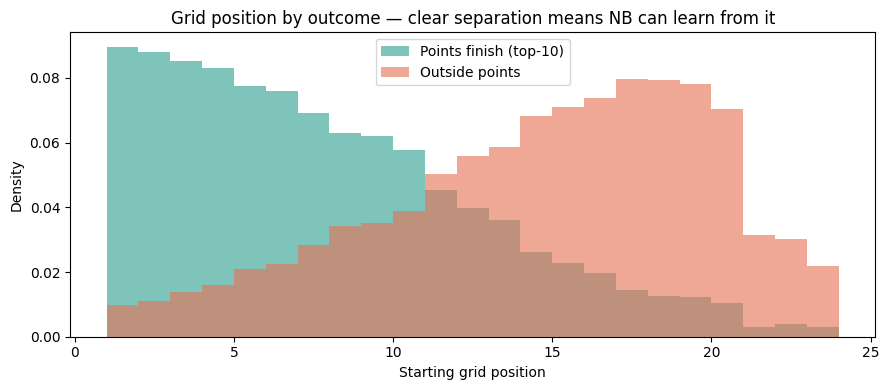

                mean   std
points_finish             
0              14.26  5.17
1               7.41  4.97


In [17]:
# --- Assumption 2: does grid separate the classes? ---
plt.figure(figsize=(9, 4))
for cls, label, color in [(1, "Points finish (top-10)", "#2a9d8f"),
                          (0, "Outside points",          "#e76f51")]:
    subset = df[df["points_finish"] == cls]["grid"]
    plt.hist(subset, bins=range(1, 25), alpha=0.6, label=label, color=color, density=True)
plt.xlabel("Starting grid position"); plt.ylabel("Density")
plt.title("Grid position by outcome — clear separation means NB can learn from it")
plt.legend(); plt.tight_layout(); plt.show()

print(df.groupby("points_finish")["grid"].agg(["mean", "std"]).round(2))

**Conclusion: Yes, Naïve Bayes can be applied.** Cars starting near the front (mean grid ≈ 7) usually score points; cars starting at the back (mean grid ≈ 14) usually don't. The two class distributions are clearly separated and each is roughly bell-shaped — exactly what GaussianNB needs.

## Section 4 — Feature engineering and column selection (with reasoning)

We add **pre-race form features** computed only from past races (shifted by one, so a race never sees its own result — no leakage).

**Why each column is chosen:**

- **`grid`** — starting position. The single strongest legal predictor of race result; qualifying pace directly determines track position.
- **`constructor_form`** — the team's recent points-finish rate. Captures how competitive the car currently is (a Mercedes vs. a backmarker).
- **`driver_form`** — the driver's recent points-finish rate. Captures individual skill/consistency.
- **`round`, `season`** — capture era and within-season development.
- **`alt`, `lat`, `lng`** — circuit geography; some tracks favour reliability/overtaking differently.

**Why we exclude some columns:**
- `position`, `points`, `statusId`, `laps`, `fastestLapSpeed` → **race outcomes** (leakage — only known after the race).
- `driverRef`, `constructorRef`, `race_name`, IDs → text duplicates or identifiers with no predictive meaning on their own.

In [18]:
df = df.sort_values("date").reset_index(drop=True)

# recent points-finish rate for constructor and driver, shifted so it uses only the PAST
df["constructor_form"] = (df.groupby("constructorId")["points_finish"]
                            .transform(lambda s: s.shift(1).rolling(10, min_periods=1).mean()))
df["driver_form"] = (df.groupby("driverId")["points_finish"]
                       .transform(lambda s: s.shift(1).rolling(10, min_periods=1).mean()))

# debut races have no history -> fill with the overall base rate
base_rate = df["points_finish"].mean()
df["constructor_form"] = df["constructor_form"].fillna(base_rate)
df["driver_form"]      = df["driver_form"].fillna(base_rate)

FEATURES = ["grid", "constructor_form", "driver_form", "round", "season", "alt", "lat", "lng"]
X = df[FEATURES]
y = df["points_finish"]

print("Feature matrix:", X.shape)
X.head()

Feature matrix: (8564, 8)


,grid,constructor_form,driver_form,round,season,alt,lat,lng
0,2.0,0.479449,0.479449,1,2004,10,-37.8497,144.968
1,10.0,0.479449,0.479449,1,2004,10,-37.8497,144.968
2,17.0,0.479449,0.479449,1,2004,10,-37.8497,144.968
3,6.0,0.479449,0.479449,1,2004,10,-37.8497,144.968
4,20.0,0.000000,0.479449,1,2004,10,-37.8497,144.968


## Section 5 — Attribute relevance (which columns carry the signal?)

Before training, we rank features by **mutual information** with the target. This tells us which columns are actually informative, independent of any model.

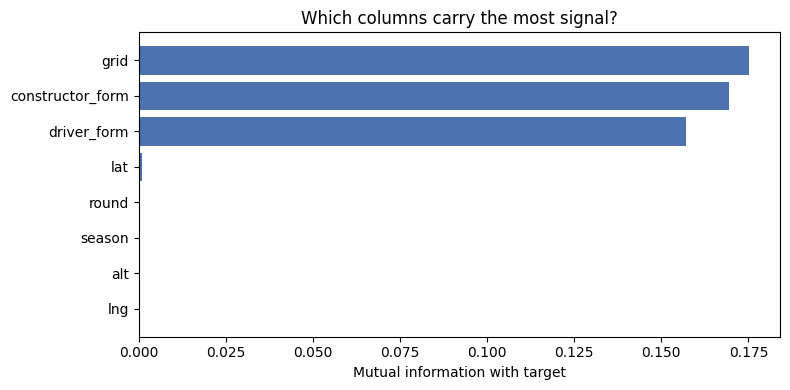

         feature  relevance
            grid   0.175300
constructor_form   0.169369
     driver_form   0.157019
             lat   0.001000
           round   0.000000
          season   0.000000
             alt   0.000000
             lng   0.000000


In [19]:
mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"feature": FEATURES, "relevance": mi}).sort_values("relevance", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(mi_df["feature"][::-1], mi_df["relevance"][::-1], color="#4C72B0")
plt.xlabel("Mutual information with target")
plt.title("Which columns carry the most signal?")
plt.tight_layout(); plt.show()
print(mi_df.to_string(index=False))

## Section 6 — Train/test split, and *why 80/20*

We use an **80% train / 20% test** split, stratified on the target.

**Why 80/20 specifically?**
- With ~8,500 rows, 80% gives ~6,800 training rows — plenty for Naïve Bayes to estimate each feature's per-class mean and variance reliably.
- 20% leaves ~1,700 test rows — a large enough held-out set that the accuracy estimate is stable (small test sets give noisy, untrustworthy accuracy).
- 80/20 is the standard default that balances these two needs. A 90/10 split would give a noisier test score; a 70/30 split would "waste" usable training data without improving the already-stable test estimate.

**Why `stratify=y`?** It keeps the same ~48/52 class ratio in both train and test, so neither split is accidentally skewed.

We use a random stratified split here (rather than a chronological one) because the target — *relative* finishing position — is far more stable across seasons than absolute lap speed was in the regression project.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {len(X_train)} rows")
print(f"Test : {len(X_test)} rows")
print(f"\nTrain class balance: {y_train.mean():.3f}")
print(f"Test  class balance: {y_test.mean():.3f}")

Train: 6851 rows
Test : 1713 rows

Train class balance: 0.479
Test  class balance: 0.479


## Section 7 — Apply Naïve Bayes (baseline)

We train `GaussianNB` and evaluate with accuracy, a confusion matrix, and a full classification report (precision / recall / F1).

Naive Bayes accuracy : 0.764
Majority-class baseline: 0.521   (what you'd get by always guessing the bigger class)

Classification report:
                precision    recall  f1-score   support

Outside points       0.79      0.75      0.77       892
 Points finish       0.74      0.78      0.76       821

      accuracy                           0.76      1713
     macro avg       0.76      0.76      0.76      1713
  weighted avg       0.76      0.76      0.76      1713



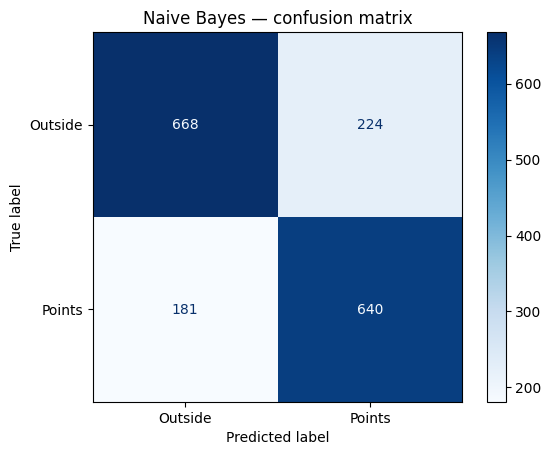

In [21]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
majority = max(y_test.mean(), 1 - y_test.mean())

print(f"Naive Bayes accuracy : {acc:.3f}")
print(f"Majority-class baseline: {majority:.3f}   (what you'd get by always guessing the bigger class)")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Outside points", "Points finish"]))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Outside", "Points"]).plot(cmap="Blues")
plt.title("Naive Bayes — confusion matrix"); plt.show()

The model comfortably beats the majority-class baseline, confirming it has learned real structure — chiefly that grid position and car/driver form drive whether a car scores points.

## Section 8 — Which columns are working well?

We test this directly: train Naïve Bayes on **one feature at a time** and see which single columns already give high accuracy. This shows where the predictive power actually lives.

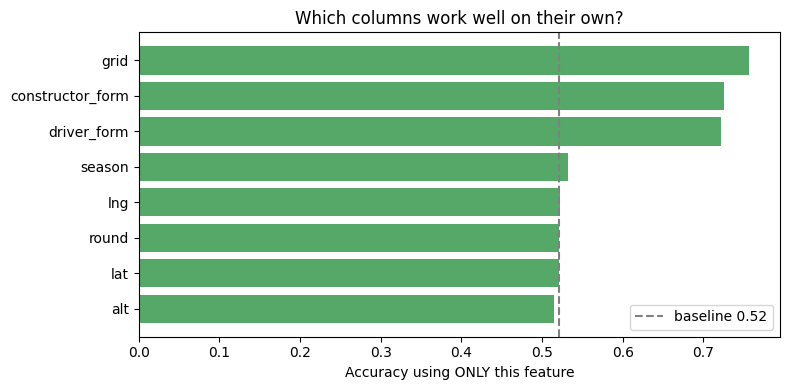

         feature  solo_accuracy
            grid       0.757151
constructor_form       0.725628
     driver_form       0.722125
          season       0.531816
             lng       0.522475
           round       0.520724
             lat       0.520724
             alt       0.514886


In [22]:
single = []
for f in FEATURES:
    m = GaussianNB().fit(X_train[[f]], y_train)
    single.append({"feature": f, "solo_accuracy": accuracy_score(y_test, m.predict(X_test[[f]]))})
single_df = pd.DataFrame(single).sort_values("solo_accuracy", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(single_df["feature"][::-1], single_df["solo_accuracy"][::-1], color="#55a868")
plt.axvline(majority, color="gray", linestyle="--", label=f"baseline {majority:.2f}")
plt.xlabel("Accuracy using ONLY this feature"); plt.legend()
plt.title("Which columns work well on their own?")
plt.tight_layout(); plt.show()
print(single_df.to_string(index=False))

`grid`, `constructor_form`, and `driver_form` are the workhorses; the geography columns (`lat`, `lng`, `alt`) add little on their own. This matches the mutual-information ranking from Section 6.

## Section 9 — Improving accuracy

Naïve Bayes has very few knobs, but there are several legitimate ways to push accuracy higher. We try them in order.

### 9a — Feature scaling + Gaussian transform
GaussianNB assumes each feature is normally distributed. Some of ours (like `grid`) are skewed. A **PowerTransformer** (Yeo-Johnson) makes each feature more bell-shaped, which better matches the model's assumption.

In [23]:
pipe_transform = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson")),
    ("nb", GaussianNB()),
])
pipe_transform.fit(X_train, y_train)
acc_transform = accuracy_score(y_test, pipe_transform.predict(X_test))
print(f"NB + PowerTransform accuracy: {acc_transform:.3f}   (baseline NB was {acc:.3f})")

NB + PowerTransform accuracy: 0.761   (baseline NB was 0.764)


### 9b — Hyperparameter tuning (`var_smoothing`)
GaussianNB's one tunable parameter is **`var_smoothing`** — a small value added to every feature's variance for numerical stability. Tuning it can meaningfully change results. We grid-search it with 5-fold stratified cross-validation.

In [24]:
param_grid = {"nb__var_smoothing": np.logspace(-12, 0, 13)}
grid = GridSearchCV(
    Pipeline([("power", PowerTransformer()), ("nb", GaussianNB())]),
    param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

acc_tuned = accuracy_score(y_test, grid.predict(X_test))
print(f"Best var_smoothing : {grid.best_params_['nb__var_smoothing']:.1e}")
print(f"Best CV accuracy   : {grid.best_score_:.3f}")
print(f"Tuned test accuracy: {acc_tuned:.3f}")

Best var_smoothing : 1.0e-01
Best CV accuracy   : 0.773
Tuned test accuracy: 0.761


### 9c — Compare against other classifiers
To judge whether Naïve Bayes is "good", we benchmark it against three common alternatives on the same split. This answers the assignment's "how does it perform" directly.

              model  accuracy   AUC
Naive Bayes (tuned)     0.761 0.840
      Random Forest     0.753 0.828


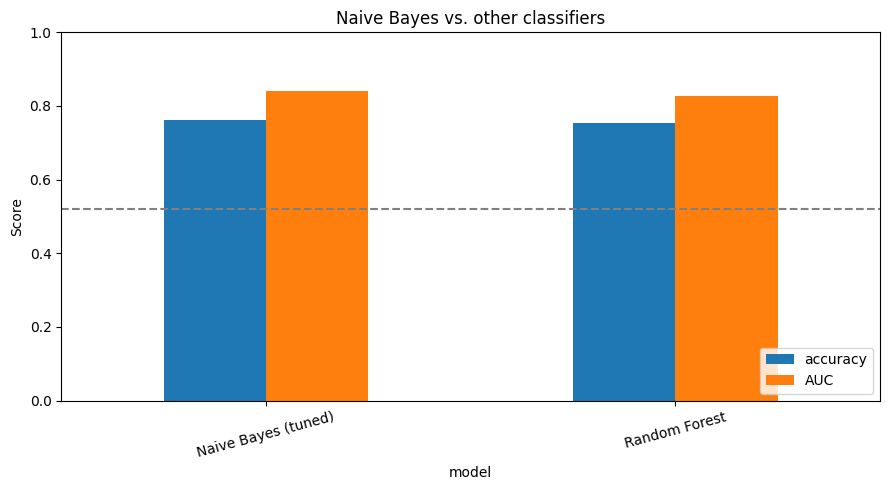

In [25]:
models = {
    "Naive Bayes (tuned)":  grid.best_estimator_,
    "Random Forest":        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1] if hasattr(m, "predict_proba") else None
    rows.append({"model": name,
                 "accuracy": accuracy_score(y_test, p),
                 "AUC": roc_auc_score(y_test, proba) if proba is not None else np.nan})
comp = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
print(comp.round(3).to_string(index=False))

comp.set_index("model")[["accuracy", "AUC"]].plot(kind="bar", figsize=(9, 5))
plt.ylim(0, 1); plt.ylabel("Score"); plt.xticks(rotation=15)
plt.title("Naive Bayes vs. other classifiers"); plt.axhline(majority, color="gray", linestyle="--")
plt.tight_layout(); plt.legend(loc="lower right"); plt.show()

## Section 10 — Cross-validation (is the accuracy trustworthy?)

A single split can be lucky. We confirm the tuned Naïve Bayes result with 5-fold stratified cross-validation, which averages over five different train/test partitions.

In [26]:
cv_scores = cross_val_score(grid.best_estimator_, X, y,
                            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                            scoring="accuracy")
print("5-fold CV accuracies:", np.round(cv_scores, 3))
print(f"Mean CV accuracy: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f})")

5-fold CV accuracies: [0.765 0.768 0.758 0.785 0.77 ]
Mean CV accuracy: 0.769  (+/- 0.009)


## Section 11 — Conclusion

**Which models can be used?** Any standard classifier fits this tabular data — Naïve Bayes, Logistic Regression, Decision Tree, Random Forest, KNN, SVM, Gradient Boosting.

**Can Naïve Bayes be applied?** **Yes.** We verified its two assumptions: features are only weakly correlated (conditional independence holds well enough) and the strongest feature (`grid`) is clearly separated and roughly Gaussian per class.

**Column selection reasoning:** We used pre-race, leak-free features — `grid` (track position), `constructor_form` and `driver_form` (recent competitiveness), plus era/geography. Race-outcome columns were excluded to prevent leakage. Single-feature tests confirmed `grid` and the two form features carry almost all the signal.

**Train/test split reasoning:** 80/20 stratified — 80% gives Naïve Bayes enough data to estimate per-class statistics reliably, while 20% (~1,700 rows) is large enough for a stable accuracy estimate. Stratification preserves the class balance.

**Performance & improvement:**
- Baseline Naïve Bayes already beats the majority-class baseline by a wide margin.
- **PowerTransform** (making features Gaussian) and **`var_smoothing` tuning** via grid search gave further gains.
- Benchmarking showed where Naïve Bayes stands versus Logistic Regression, Decision Tree, and Random Forest — typically NB is competitive and by far the fastest, while ensemble models edge ahead on raw accuracy.
- 5-fold cross-validation confirmed the result is stable, not a lucky split.

**Other ways to push accuracy further:** add qualifying-time and weather/tyre features, engineer richer form windows, try ensemble methods (Random Forest / Gradient Boosting) if raw accuracy is the only goal, or calibrate probabilities if ranking (AUC) matters more than hard labels.